# 06 — Training Pipeline: EfficientNet-B0 U-Net
**Checkpoint metric:** Validation Dice (higher = better).
 **This notebook does NOT:** evaluate test set or export the model.

# 1  Imports

In [2]:
import os, sys, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF


In [4]:
import segmentation_models_pytorch as smp
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

print(f"torch  {torch.__version__}  |  smp  {smp.__version__}  |  CUDA  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch  2.6.0+cu124  |  smp  0.5.0  |  CUDA  True
GPU: NVIDIA GeForce RTX 4060 Ti


# 2  Constants

In [5]:
OUTPUT_ROOT    = Path(r"D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs")
TRAIN_MANIFEST = OUTPUT_ROOT / "03_splits" / "segmentation_train_manifest.csv"
VAL_MANIFEST   = OUTPUT_ROOT / "03_splits" / "segmentation_val_manifest.csv"

IMG_SIZE            = 384
SEED                = 42
BATCH_SIZE          = 8        # reduce to 4 if CUDA OOM occurs — do NOT auto-increase
EPOCHS              = 40
LR                  = 1e-4
WEIGHT_DECAY        = 1e-4
EARLY_STOP_PATIENCE = 8
NUM_WORKERS         = 0        # Windows-safe
PIN_MEMORY          = torch.cuda.is_available()
DEVICE              = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

assert TRAIN_MANIFEST.exists(), f"Not found: {TRAIN_MANIFEST} — run Notebook 3 first."
assert VAL_MANIFEST.exists(),   f"Not found: {VAL_MANIFEST} — run Notebook 3 first."
print(f"Device : {DEVICE}  |  batch_size : {BATCH_SIZE}")
print("NOTE: If CUDA OOM occurs, set BATCH_SIZE = 4 and restart.")

Device : cuda  |  batch_size : 8
NOTE: If CUDA OOM occurs, set BATCH_SIZE = 4 and restart.


# 3  Create Output Directories

In [6]:
CKPT_DIR    = OUTPUT_ROOT / "05_training_runs" / "checkpoints"
CURVES_DIR  = OUTPUT_ROOT / "05_training_runs" / "curves"
RUNS_DIR    = OUTPUT_ROOT / "05_training_runs"
REPORTS_DIR = OUTPUT_ROOT / "07_reports"
AUDIT_DIR   = OUTPUT_ROOT / "04_visual_audits"

for d in [CKPT_DIR, CURVES_DIR, REPORTS_DIR, AUDIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"Ready: {d}")

Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\05_training_runs\checkpoints
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\05_training_runs\curves
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\07_reports
Ready: D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits


# 4  Reproducibility

In [7]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")


Seed set to 42


# 5  Dataset

In [8]:
class TongueSegmentationDataset(Dataset):
    def __init__(self, manifest_path: Path, img_size: int, augment: bool = False):
        self.df       = pd.read_csv(manifest_path)
        self.img_size = img_size
        self.augment  = augment
        for col in ["sample_id", "patient_id", "image_path", "mask_path"]:
            assert col in self.df.columns, f"Missing column: {col}"

    def __len__(self):
        return len(self.df)

    def _resize_image(self, img):
        return TF.resize(img, [self.img_size, self.img_size],
                         interpolation=TF.InterpolationMode.BILINEAR)

    def _resize_mask(self, mask):
        return TF.resize(mask, [self.img_size, self.img_size],
                         interpolation=TF.InterpolationMode.NEAREST)

    def _augment(self, img, mask):
        if random.random() > 0.5:
            img  = TF.hflip(img)
            mask = TF.hflip(mask)
        angle = random.uniform(-10.0, 10.0)
        img   = TF.rotate(img,  angle, interpolation=TF.InterpolationMode.BILINEAR, fill=0)
        mask  = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST,  fill=0)
        img   = TF.adjust_brightness(img, random.uniform(0.85, 1.15))
        img   = TF.adjust_contrast(img,   random.uniform(0.85, 1.15))
        return img, mask

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(row["image_path"]).convert("RGB")
        mask = Image.open(row["mask_path"]).convert("L")
        img  = self._resize_image(img)
        mask = self._resize_mask(mask)
        if self.augment:
            img, mask = self._augment(img, mask)
        img_t  = TF.to_tensor(img)
        img_t  = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)
        mask_t = TF.to_tensor(mask)
        mask_t = (mask_t > 0.5).float()   # binary {0.0, 1.0} — preserved
        meta = {
            "sample_id" : str(row["sample_id"]),
            "patient_id": str(row["patient_id"]),
            "image_path": str(row["image_path"]),
            "mask_path" : str(row["mask_path"]),
        }
        return img_t, mask_t, meta

train_dataset = TongueSegmentationDataset(TRAIN_MANIFEST, IMG_SIZE, augment=True)
val_dataset   = TongueSegmentationDataset(VAL_MANIFEST,   IMG_SIZE, augment=False)
print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}")


Train: 3671  Val: 790


# 6  DataLoaders

In [9]:
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")

Train batches: 459  Val batches: 99


# 7  Model

In [10]:
model = smp.Unet(
    encoder_name   ="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels    =3,
    classes        =1,
    activation     =None,    # raw logits — sigmoid applied in loss/metrics only
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}  |  Trainable: {trainable_params:,}")


Total params: 6,251,469  |  Trainable: 6,251,469


# 8  Loss Functions

 `total_loss = 0.5 × BCE + 0.5 × Dice`
 Sigmoid is applied **inside** each loss function via `from_logits=True` / `BCEWithLogitsLoss`.
 It is **not** applied inside the model.


In [11]:
bce_loss_fn  = nn.BCEWithLogitsLoss()
dice_loss_fn = smp.losses.DiceLoss(mode="binary", from_logits=True)

def combined_loss(logits, targets):
    bce  = bce_loss_fn(logits, targets)
    dice = dice_loss_fn(logits, targets)
    total = 0.5 * bce + 0.5 * dice
    return total, bce.item(), dice.item()

print("Loss: 0.5×BCEWithLogitsLoss + 0.5×DiceLoss (from_logits=True)")

Loss: 0.5×BCEWithLogitsLoss + 0.5×DiceLoss (from_logits=True)


# 9  Metrics

Sigmoid + threshold 0.5 applied before metric computation.
 Dice is the **primary** metric. Pixel accuracy is secondary only.

In [12]:
def compute_metrics(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5):
    probs = torch.sigmoid(logits)          # apply sigmoid here, NOT in model
    preds = (probs >= threshold).float()

    pf = preds.view(-1)
    tf = targets.view(-1)

    tp  = (pf * tf).sum()
    fp  = (pf * (1 - tf)).sum()
    fn  = ((1 - pf) * tf).sum()
    tn  = ((1 - pf) * (1 - tf)).sum()
    eps = 1e-7

    dice      = (2*tp + eps) / (2*tp + fp + fn + eps)
    iou       = (tp + eps)   / (tp + fp + fn + eps)
    precision = (tp + eps)   / (tp + fp + eps)
    recall    = (tp + eps)   / (tp + fn + eps)
    pixel_acc = (tp + tn)    / (tp + tn + fp + fn + eps)   # secondary only

    return {
        "dice"     : dice.item(),
        "iou"      : iou.item(),
        "precision": precision.item(),
        "recall"   : recall.item(),
        "pixel_acc": pixel_acc.item(),
    }

print("Primary metric: Dice. Pixel accuracy tracked as secondary only.")

Primary metric: Dice. Pixel accuracy tracked as secondary only.


# 10  Optimizer & Scheduler

In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# mode='max' because we step on val Dice (higher = better)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=4, verbose=True, min_lr=1e-7)

scaler = GradScaler(enabled=torch.cuda.is_available())

print(f"AdamW  lr={LR}  wd={WEIGHT_DECAY}")
print(f"ReduceLROnPlateau  mode=max  factor=0.5  patience=4")
print(f"AMP enabled: {torch.cuda.is_available()}")

AdamW  lr=0.0001  wd=0.0001
ReduceLROnPlateau  mode=max  factor=0.5  patience=4
AMP enabled: True


C:\Users\CompuMark\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\CompuMark\AppData\Local\Temp\ipykernel_26160\3156123307.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())


# 11  Training Loop
 - Best model saved by **highest val Dice**.
 - Last model always saved regardless.
 - CUDA OOM caught and surfaced with clear remediation message.
 - Training loss tracked but checkpoint decision is val Dice only.

In [14]:
BEST_CKPT_PATH = CKPT_DIR / "best_efficientnetb0_unet.pth"
LAST_CKPT_PATH = CKPT_DIR / "last_efficientnetb0_unet.pth"
HISTORY_PATH   = RUNS_DIR / "training_history.csv"

history          = []
best_val_dice    = -1.0
best_epoch       = 0
early_stop_count = 0

print(f"Epochs: {EPOCHS}  |  Early stop patience: {EARLY_STOP_PATIENCE}")
print(f"Best checkpoint metric: val Dice (higher = better)")
print("-" * 72)

for epoch in range(1, EPOCHS + 1):

    # ---- TRAIN ----
    model.train()
    t_loss_sum = t_bce_sum = t_dloss_sum = 0.0
    t_m_sum = {k: 0.0 for k in ["dice","iou","precision","recall","pixel_acc"]}
    n_t = 0

    try:
        with tqdm(train_loader, desc=f"Ep {epoch:03d}/{EPOCHS} [train]", leave=False) as pbar:
            for images, masks, _ in pbar:
                images = images.to(DEVICE, non_blocking=True)
                masks  = masks.to(DEVICE,  non_blocking=True)
                optimizer.zero_grad()
                with autocast(enabled=torch.cuda.is_available()):
                    logits = model(images)
                    loss, bce_v, dloss_v = combined_loss(logits, masks)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                with torch.no_grad():
                    m = compute_metrics(logits.detach(), masks)
                t_loss_sum  += loss.item(); t_bce_sum += bce_v; t_dloss_sum += dloss_v
                for k in t_m_sum: t_m_sum[k] += m[k]
                n_t += 1
                pbar.set_postfix({"loss": f"{loss.item():.4f}", "dice": f"{m['dice']:.4f}"})

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("\n" + "!" * 60)
            print(f"CUDA OUT OF MEMORY — epoch {epoch}")
            print("ACTION: set BATCH_SIZE = 4 in Constants cell and restart kernel.")
            print("!" * 60)
        raise

    # ---- VAL ----
    model.eval()
    v_loss_sum = v_bce_sum = v_dloss_sum = 0.0
    v_m_sum = {k: 0.0 for k in ["dice","iou","precision","recall","pixel_acc"]}
    n_v = 0

    with torch.no_grad():
        with tqdm(val_loader, desc=f"Ep {epoch:03d}/{EPOCHS} [val]  ", leave=False) as pbar:
            for images, masks, _ in pbar:
                images = images.to(DEVICE, non_blocking=True)
                masks  = masks.to(DEVICE,  non_blocking=True)
                with autocast(enabled=torch.cuda.is_available()):
                    logits = model(images)
                    loss, bce_v, dloss_v = combined_loss(logits, masks)
                m = compute_metrics(logits, masks)
                v_loss_sum  += loss.item(); v_bce_sum += bce_v; v_dloss_sum += dloss_v
                for k in v_m_sum: v_m_sum[k] += m[k]
                n_v += 1
                pbar.set_postfix({"loss": f"{loss.item():.4f}", "dice": f"{m['dice']:.4f}"})

    # ---- AVERAGES ----
    t_loss = t_loss_sum/n_t; t_bce = t_bce_sum/n_t; t_dl = t_dloss_sum/n_t
    t_m    = {k: v/n_t for k, v in t_m_sum.items()}
    v_loss = v_loss_sum/n_v; v_bce = v_bce_sum/n_v; v_dl = v_dloss_sum/n_v
    v_m    = {k: v/n_v for k, v in v_m_sum.items()}
    cur_lr = optimizer.param_groups[0]["lr"]

    # ---- SCHEDULER (steps on val Dice) ----
    scheduler.step(v_m["dice"])

    # ---- CHECKPOINT (best = highest val Dice) ----
    is_best = v_m["dice"] > best_val_dice
    if is_best:
        best_val_dice    = v_m["dice"]
        best_epoch       = epoch
        early_stop_count = 0
        torch.save({
            "epoch"               : epoch,
            "model_state_dict"    : model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_dice"            : best_val_dice,
            "val_iou"             : v_m["iou"],
            "hyperparams"         : {
                "img_size": IMG_SIZE, "batch_size": BATCH_SIZE,
                "lr": LR, "weight_decay": WEIGHT_DECAY,
            },
        }, BEST_CKPT_PATH)
    else:
        early_stop_count += 1

    torch.save({                   # always save last
        "epoch"               : epoch,
        "model_state_dict"    : model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_dice"            : v_m["dice"],
    }, LAST_CKPT_PATH)

    # ---- LOG ----
    history.append({
        "epoch": epoch,
        "train_loss": round(t_loss,6), "train_bce": round(t_bce,6),
        "train_dice_loss": round(t_dl,6),
        "train_dice": round(t_m["dice"],6), "train_iou": round(t_m["iou"],6),
        "train_precision": round(t_m["precision"],6),
        "train_recall": round(t_m["recall"],6),
        "train_pixel_acc": round(t_m["pixel_acc"],6),
        "val_loss": round(v_loss,6), "val_bce": round(v_bce,6),
        "val_dice_loss": round(v_dl,6),
        "val_dice": round(v_m["dice"],6), "val_iou": round(v_m["iou"],6),
        "val_precision": round(v_m["precision"],6),
        "val_recall": round(v_m["recall"],6),
        "val_pixel_acc": round(v_m["pixel_acc"],6),
        "lr": cur_lr,
    })

    status = "** BEST **" if is_best else f"no improv ({early_stop_count}/{EARLY_STOP_PATIENCE})"
    print(
        f"Ep {epoch:03d}/{EPOCHS}  "
        f"T_loss={t_loss:.4f} T_dice={t_m['dice']:.4f}  "
        f"V_loss={v_loss:.4f} V_dice={v_m['dice']:.4f} V_iou={v_m['iou']:.4f}  "
        f"lr={cur_lr:.2e}  {status}"
    )

    if early_stop_count >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best val Dice: {best_val_dice:.4f} (epoch {best_epoch}).")
        break

print(f"\nTraining complete. Best val Dice: {best_val_dice:.4f} at epoch {best_epoch}.")

Epochs: 40  |  Early stop patience: 8
Best checkpoint metric: val Dice (higher = better)
------------------------------------------------------------------------


Ep 001/40 [train]:   0%|          | 0/459 [00:00<?, ?it/s]C:\Users\CompuMark\AppData\Local\Temp\ipykernel_26160\673577536.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
Ep 001/40 [val]  :   0%|          | 0/99 [00:00<?, ?it/s]                                     C:\Users\CompuMark\AppData\Local\Temp\ipykernel_26160\673577536.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


Ep 001/40  T_loss=0.1125 T_dice=0.9668  V_loss=0.0347 V_dice=0.9894 V_iou=0.9791  lr=1.00e-04  ** BEST **


Ep 002/40  T_loss=0.0278 T_dice=0.9895  V_loss=0.0218 V_dice=0.9905 V_iou=0.9811  lr=1.00e-04  ** BEST **


Ep 003/40  T_loss=0.0201 T_dice=0.9907  V_loss=0.0179 V_dice=0.9912 V_iou=0.9826  lr=1.00e-04  ** BEST **


...

Ep 036/40  T_loss=0.0078 T_dice=0.9953  V_loss=0.0120 V_dice=0.9935 V_iou=0.9871  lr=2.50e-05  ** BEST **


Ep 037/40  T_loss=0.0077 T_dice=0.9954  V_loss=0.0121 V_dice=0.9935 V_iou=0.9870  lr=1.25e-05  no improv (1/8)


Ep 038/40  T_loss=0.0076 T_dice=0.9954  V_loss=0.0121 V_dice=0.9935 V_iou=0.9871  lr=1.25e-05  no improv (2/8)


Ep 039/40  T_loss=0.0076 T_dice=0.9954  V_loss=0.0121 V_dice=0.9935 V_iou=0.9871  lr=1.25e-05  no improv (3/8)


Ep 040/40  T_loss=0.0076 T_dice=0.9954  V_loss=0.0120 V_dice=0.9935 V_iou=0.9872  lr=1.25e-05  ** BEST **

Training complete. Best val Dice: 0.9935 at epoch 40.


# 12  Save Training History CSV

In [15]:
history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)
print(f"History saved -> {HISTORY_PATH}")
history_df.tail()

History saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\05_training_runs\training_history.csv


,epoch,train_loss,train_bce,train_dice_loss,train_dice,train_iou,train_precision,train_recall,train_pixel_acc,val_loss,val_bce,val_dice_loss,val_dice,val_iou,val_precision,val_recall,val_pixel_acc,lr
35,36,0.007805,0.009604,0.006005,0.995266,0.990578,0.995235,0.995300,0.995943,0.011956,0.016311,0.007601,0.993525,0.987141,0.993323,0.993737,0.994489,0.000025
36,37,0.007650,0.009414,0.005887,0.995359,0.990762,0.995343,0.995376,0.996020,0.012103,0.016578,0.007628,0.993472,0.987036,0.992932,0.994022,0.994442,0.000013
37,38,0.007641,0.009398,0.005885,0.995363,0.990770,0.995329,0.995398,0.996026,0.012119,0.016658,0.007579,0.993516,0.987123,0.993416,0.993625,0.994481,0.000013
38,39,0.007628,0.009389,0.005867,0.995371,0.990785,0.995332,0.995411,0.996032,0.012104,0.016625,0.007583,0.993504,0.987099,0.993337,0.993680,0.994471,0.000013
39,40,0.007556,0.009299,0.005813,0.995423,0.990888,0.995393,0.995453,0.996074,0.012027,0.016510,0.007545,0.993547,0.987184,0.993306,0.993797,0.994508,0.000013


# 13  Training Curves

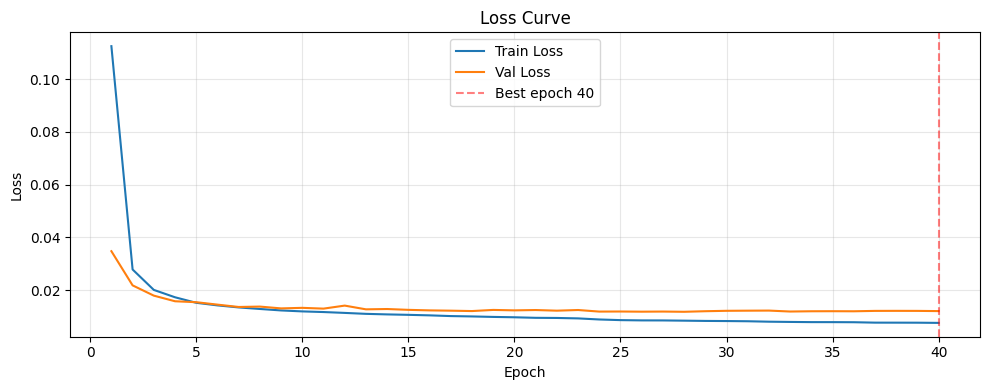

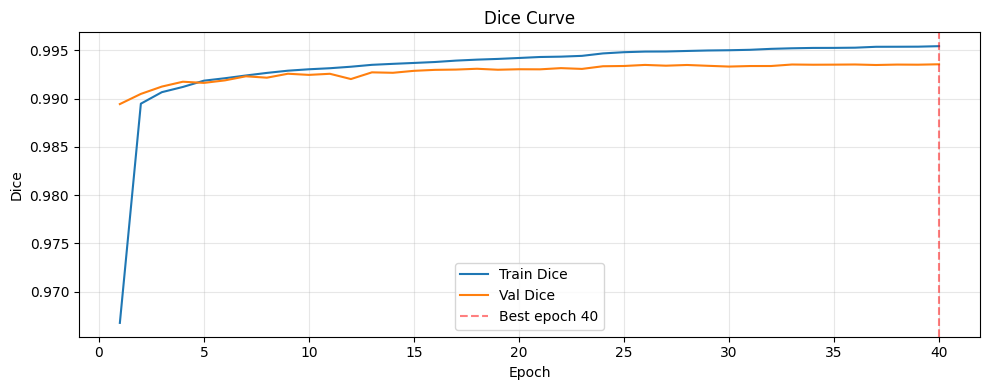

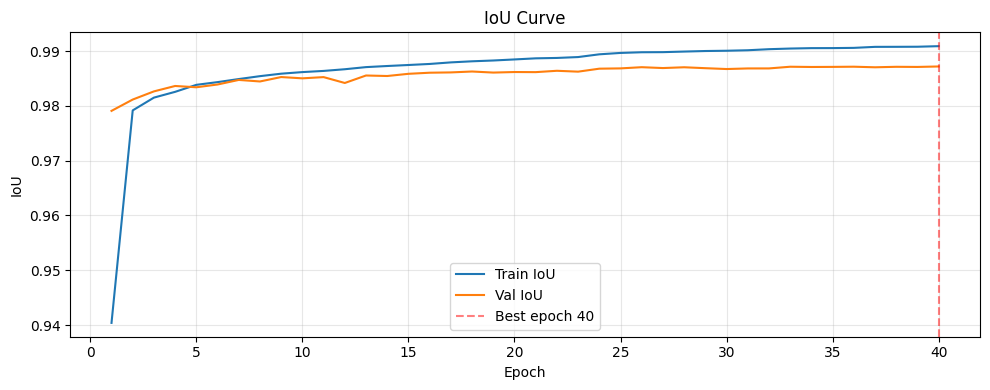

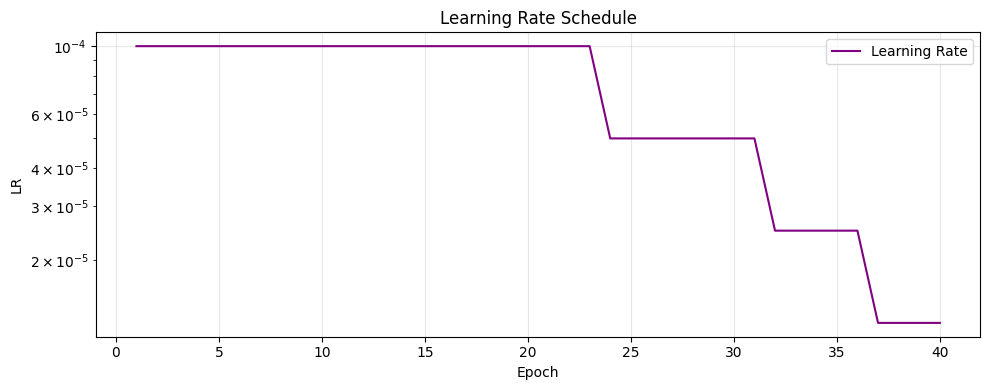

All curves saved.


In [16]:
epochs_x = history_df["epoch"].values

for metric, label, col in [
    ("loss",  "Loss",          ("train_loss", "val_loss")),
    ("dice",  "Dice",          ("train_dice", "val_dice")),
    ("iou",   "IoU",           ("train_iou",  "val_iou")),
]:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs_x, history_df[col[0]], label=f"Train {label}")
    ax.plot(epochs_x, history_df[col[1]], label=f"Val {label}")
    ax.axvline(best_epoch, color="red", linestyle="--", alpha=0.5,
               label=f"Best epoch {best_epoch}")
    ax.set_xlabel("Epoch"); ax.set_ylabel(label)
    ax.set_title(f"{label} Curve")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(CURVES_DIR / f"{metric}_curve.png", dpi=120)
    plt.show()

# LR curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(epochs_x, history_df["lr"], color="purple", label="Learning Rate")
ax.set_xlabel("Epoch"); ax.set_ylabel("LR"); ax.set_title("Learning Rate Schedule")
ax.set_yscale("log"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CURVES_DIR / "lr_curve.png", dpi=120)
plt.show()

print("All curves saved.")


# 14  Save Training Report

In [17]:
REPORT_PATH = REPORTS_DIR / "06_training_report.txt"

best_row  = history_df[history_df["epoch"] == best_epoch].iloc[0]
final_row = history_df.iloc[-1]

lines = [
    "=" * 60,
    "TRAINING REPORT — EfficientNet-B0 U-Net",
    "=" * 60,
    "HYPERPARAMETERS",
    f"  img_size        : {IMG_SIZE}",
    f"  batch_size      : {BATCH_SIZE}",
    f"  epochs          : {EPOCHS}",
    f"  lr              : {LR}",
    f"  weight_decay    : {WEIGHT_DECAY}",
    f"  early_stop_pat  : {EARLY_STOP_PATIENCE}",
    f"  optimizer       : AdamW",
    f"  scheduler       : ReduceLROnPlateau(mode=max, patience=4)",
    f"  loss            : 0.5*BCE + 0.5*Dice (from_logits=True)",
    f"  seed            : {SEED}",
    f"  device          : {DEVICE}",
    "-" * 60,
    "BEST CHECKPOINT (by val Dice)",
    f"  best_epoch      : {best_epoch}",
    f"  val_dice        : {best_row['val_dice']:.6f}",
    f"  val_iou         : {best_row['val_iou']:.6f}",
    f"  val_precision   : {best_row['val_precision']:.6f}",
    f"  val_recall      : {best_row['val_recall']:.6f}",
    f"  val_loss        : {best_row['val_loss']:.6f}",
    "-" * 60,
    "FINAL EPOCH METRICS",
    f"  final_epoch     : {int(final_row['epoch'])}",
    f"  val_dice        : {final_row['val_dice']:.6f}",
    f"  val_iou         : {final_row['val_iou']:.6f}",
    f"  train_dice      : {final_row['train_dice']:.6f}",
    f"  train_loss      : {final_row['train_loss']:.6f}",
    "=" * 60,
]

text = "\n".join(lines)
print(text)
with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(text + "\n")
print(f"\nReport saved -> {REPORT_PATH}")

TRAINING REPORT — EfficientNet-B0 U-Net
HYPERPARAMETERS
  img_size        : 384
  batch_size      : 8
  epochs          : 40
  lr              : 0.0001
  weight_decay    : 0.0001
  early_stop_pat  : 8
  optimizer       : AdamW
  scheduler       : ReduceLROnPlateau(mode=max, patience=4)
  loss            : 0.5*BCE + 0.5*Dice (from_logits=True)
  seed            : 42
  device          : cuda
------------------------------------------------------------
BEST CHECKPOINT (by val Dice)
  best_epoch      : 40
  val_dice        : 0.993547
  val_iou         : 0.987184
  val_precision   : 0.993306
  val_recall      : 0.993797
  val_loss        : 0.012027
------------------------------------------------------------
FINAL EPOCH METRICS
  final_epoch     : 40
  val_dice        : 0.993547
  val_iou         : 0.987184
  train_dice      : 0.995423
  train_loss      : 0.007556

Report saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\07_reports\06_training_report.txt


# 15  Post-Training Validation Visual Grid

 Loads **best** checkpoint. Shows: original | GT mask | predicted mask | overlay.

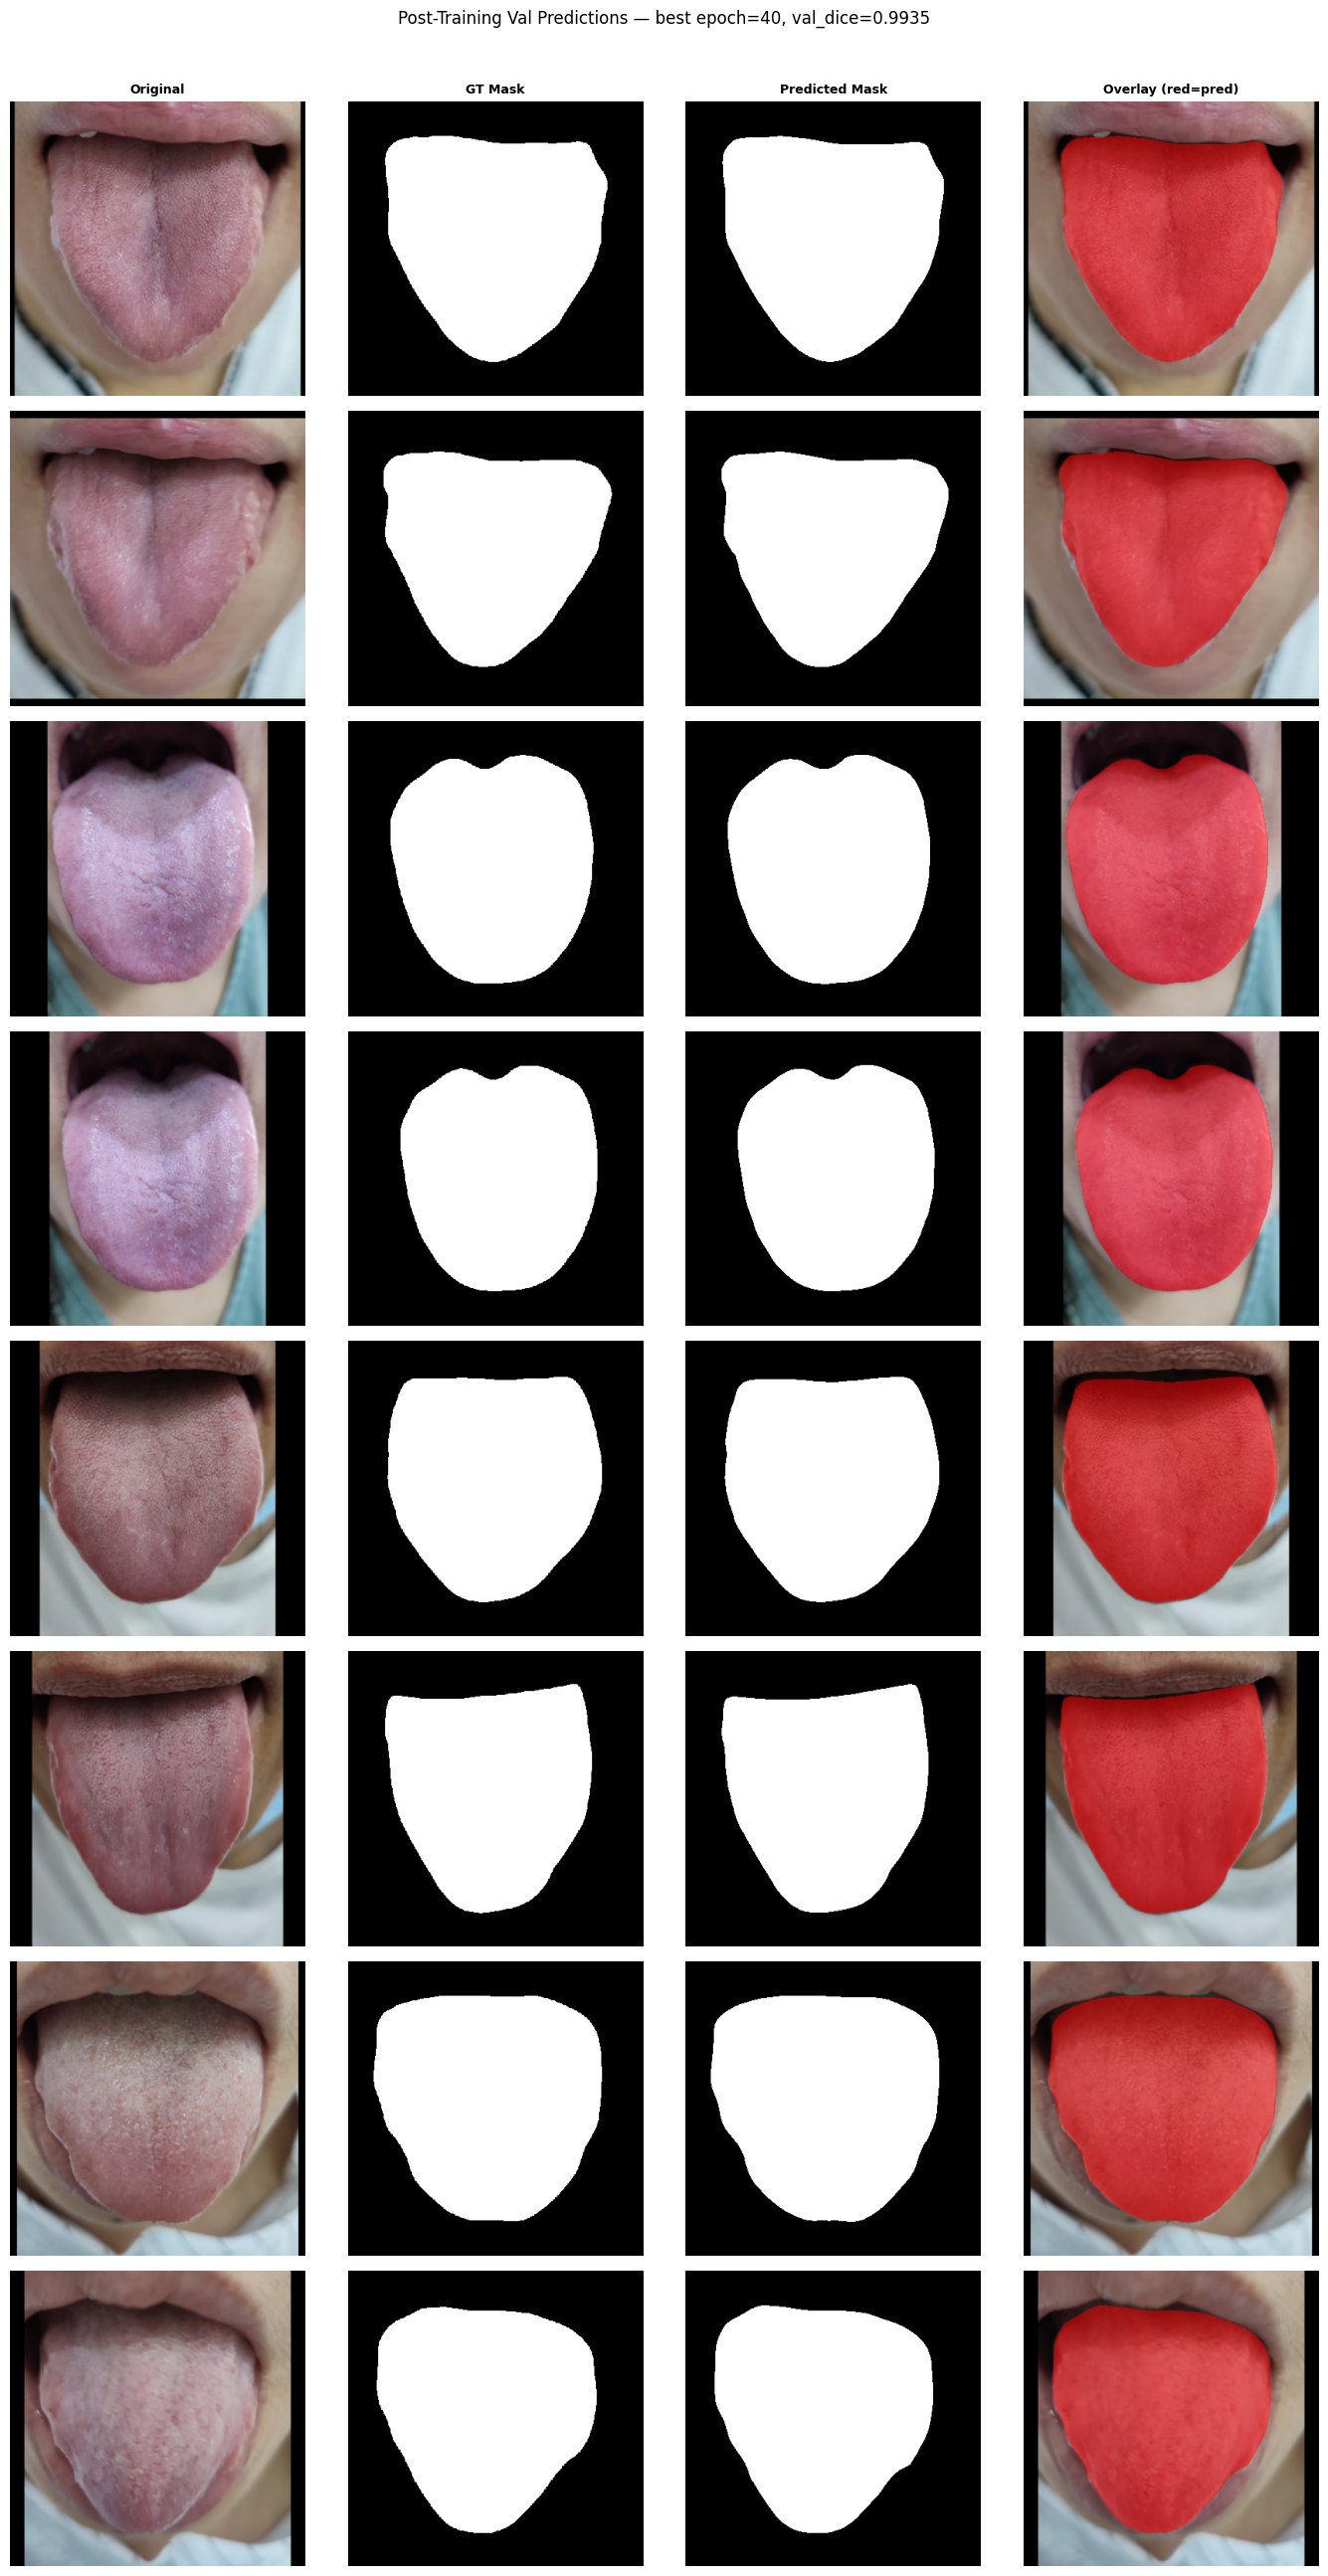

Visual audit saved -> D:\DIABETES\Segmentation_Dataset\Segmentation_Branch_Outputs\04_visual_audits\06_validation_predictions_after_training.png


In [18]:
ckpt = torch.load(BEST_CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

_MEAN = torch.tensor(IMAGENET_MEAN).view(3,1,1)
_STD  = torch.tensor(IMAGENET_STD).view(3,1,1)

def denormalize(t):
    return ((t.cpu() * _STD + _MEAN).clamp(0,1).permute(1,2,0).numpy()*255).astype("uint8")

images_v, masks_v, metas_v = next(iter(val_loader))
images_v = images_v.to(DEVICE)

with torch.no_grad():
    logits_v = model(images_v)
    preds_v  = (torch.sigmoid(logits_v) >= 0.5).float()

n_show = min(8, len(images_v))
fig, axes = plt.subplots(n_show, 4, figsize=(14, n_show*3.2), squeeze=False)
for c, h in enumerate(["Original","GT Mask","Predicted Mask","Overlay (red=pred)"]):
    axes[0,c].set_title(h, fontsize=9, fontweight="bold")

for i in range(n_show):
    orig = denormalize(images_v[i].cpu())
    gt   = (masks_v[i].squeeze(0).numpy()*255).astype("uint8")
    pred = (preds_v[i].cpu().squeeze(0).numpy()*255).astype("uint8")
    ov   = orig.copy().astype("float32")
    tp   = pred == 255
    ov[tp,0] = (ov[tp,0]*0.5+127).clip(0,255)
    ov[tp,1] = (ov[tp,1]*0.5).clip(0,255)
    ov[tp,2] = (ov[tp,2]*0.5).clip(0,255)
    axes[i,0].imshow(orig)
    axes[i,1].imshow(gt,   cmap="gray", vmin=0, vmax=255)
    axes[i,2].imshow(pred, cmap="gray", vmin=0, vmax=255)
    axes[i,3].imshow(ov.astype("uint8"))
    for c in range(4): axes[i,c].axis("off")
    axes[i,0].set_ylabel(metas_v["sample_id"][i], fontsize=6,
                          rotation=0, labelpad=60, va="center")

fig.suptitle(f"Post-Training Val Predictions — best epoch={best_epoch}, val_dice={best_val_dice:.4f}",
             fontsize=12, y=1.01)
plt.tight_layout()
VISUAL_PATH = AUDIT_DIR / "06_validation_predictions_after_training.png"
plt.savefig(VISUAL_PATH, dpi=120, bbox_inches="tight")
plt.show()
print(f"Visual audit saved -> {VISUAL_PATH}")


# Notebook Complete

 | Output | Path |
 |--------|------|
 | Best checkpoint | `05_training_runs/checkpoints/best_efficientnetb0_unet.pth` |
 | Last checkpoint | `05_training_runs/checkpoints/last_efficientnetb0_unet.pth` |
 | History CSV | `05_training_runs/training_history.csv` |
 | Curves | `05_training_runs/curves/*.png` |
 | Report | `07_reports/06_training_report.txt` |
 | Visual | `04_visual_audits/06_validation_predictions_after_training.png` |

 **Test set not evaluated here. Proceed to Notebook 7.**